# ML project - Getting SNR and Mismatch from the predicted dephasing

In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports & Setup                                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d
from tqdm import tqdm
from google.colab import drive
# Run this cell first, then restart runtime
import subprocess
subprocess.run(["pip", "install", "sympy==1.12", "-q"])

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "sympy==1.12", "--force-reinstall", "--no-cache-dir", "-q"])
# Then immediately import and verify
import sympy
print("sympy version:", sympy.__version__)   # must print 1.12

drive.mount('/content/drive')
folder_path = "/content/drive/MyDrive/Machine_Learning_Project/ML4Ph_data/data"
DATA_DIR    = folder_path

K = 60   # PCA components — defined once here, never redefined below

torch.manual_seed(0)
np.random.seed(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else
                      ("mps"  if torch.backends.mps.is_available() else "cpu"))
print("device:", DEVICE)
print("K     :", K)

sympy version: 1.12
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cpu
K     : 60


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Load raw data                                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
files = sorted(glob.glob(os.path.join(DATA_DIR, "dephasing_sample_*.csv")),
               key=lambda p: int(re.search(r"_(\d+)\.csv$", p).group(1)))
print("n files:", len(files))

def parse_file(path):
    with open(path) as fh:
        lines = fh.readlines()
    params = {}
    for item in lines[0].strip().split(","):
        k, v = item.split("=")
        params[k.strip()] = float(v)
    data = np.loadtxt(lines[2:], delimiter=",")
    return params, data[:, 0], data[:, 1]   # f [Hz], dPh [rad]

m1  = np.empty(len(files))
m2  = np.empty(len(files))
rho = np.empty(len(files))
gsp = np.empty(len(files))
fs, dphis = [], []
for i, fp in tqdm(enumerate(files)):
    p, f, d = parse_file(fp)
    m1[i], m2[i], rho[i], gsp[i] = p["m1"], p["m2"], p["rhosp"], p["gsp"]
    fs.append(f); dphis.append(d)

# ── Sanity checks ──────────────────────────────────────────────────────────────
print("\n── param ranges ──")
print(f"m1     : [{m1.min():.3e}, {m1.max():.3e}]")
print(f"m2     : [{m2.min():.3e}, {m2.max():.3e}]")
print(f"rho    : [{rho.min():.3e}, {rho.max():.3e}]")
print(f"gsp    : [{gsp.min():.3f}, {gsp.max():.3f}]")
print(f"points/curve (first 5): {[len(d) for d in dphis[:5]]}")

print("\n── dphi sanity (working in dphi, NOT ln dphi) ──")
print(f"dphi range across all systems  : [{min(d.min() for d in dphis):.3e}, {max(d.max() for d in dphis):.3e}]")
print(f"any dphi <= 0 (excl. merger pt): {any((d[:-1] <= 0).any() for d in dphis)}")
print(f"last point == 0 for all        : {all(d[-1] == 0 for d in dphis)}")

# Check how many decades dphi spans — expect large range → motivates PCA on dphi
ranges_decades = [np.log10(d[:-1].max()) - np.log10(d[:-1].min()) for d in dphis]
print(f"dphi decades spanned per curve : mean={np.mean(ranges_decades):.1f}, max={np.max(ranges_decades):.1f}")
print("⚠  NOTE: dphi spans many decades — PCA coefficients will be large.")
print("   We will standardize coefficients before training.")

n files: 10000


10000it [03:48, 43.78it/s]



── param ranges ──
m1     : [1.001e+03, 9.997e+05]
m2     : [3.001e+00, 1.000e+02]
rho    : [1.001e+01, 9.993e+03]
gsp    : [2.000, 2.500]
points/curve (first 5): [200, 200, 200, 200, 200]

── dphi sanity (working in dphi, NOT ln dphi) ──
dphi range across all systems  : [0.000e+00, 2.297e+06]
any dphi <= 0 (excl. merger pt): False
last point == 0 for all        : True
dphi decades spanned per curve : mean=6.1, max=8.3
⚠  NOTE: dphi spans many decades — PCA coefficients will be large.
   We will standardize coefficients before training.


# Frequency Normalization

In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Physical frequency normalization                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
G    = 6.67430e-11
C    = 2.99792458e8
MSUN = 1.98892e30
YR   = 365.25 * 86400.0
TAU_YR = 4.0

def f_isco(m1_msun, m2_msun):
    M = (m1_msun + m2_msun) * MSUN
    return C**3 / (6**1.5 * np.pi * G * M)

def f_tau(m1_msun, m2_msun, tau_sec=TAU_YR * YR):
    Mc = (m1_msun * m2_msun)**(3/5) / (m1_msun + m2_msun)**(1/5) * MSUN
    return (1.0 / np.pi) * (5.0 / (256.0 * tau_sec))**(3/8) * (G * Mc / C**3)**(-5/8)

fc        = f_isco(m1, m2)
f_tau_arr = f_tau(m1, m2)

# ── Sanity checks ──────────────────────────────────────────────────────────────
print(f"fc        range: [{fc.min():.4e}, {fc.max():.4e}]")
print(f"f_{TAU_YR:g}yr  range: [{f_tau_arr.min():.4e}, {f_tau_arr.max():.4e}]")

fmin_data = np.array([f[0]  for f in fs])
fmax_data = np.array([f[-1] for f in fs])
print(f"\nfmin_data / f_tau (median): {np.median(fmin_data / f_tau_arr):.4f}  (want ≈ 1)")
print(f"fmax_data / fc    (median): {np.median(fmax_data / fc):.4f}  (want ≈ 1)")

fc        range: [4.3973e-03, 4.3774e+00]
f_4yr  range: [7.8091e-04, 1.6024e-02]

fmin_data / f_tau (median): 0.9199  (want ≈ 1)
fmax_data / fc    (median): 1.0010  (want ≈ 1)


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — LISA PSD                                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
L      = 2.5e9
f_star = C / (2 * np.pi * L)

def P_OMS(f): return (1.5e-11)**2 * (1 + (2e-3 / f)**4)
def P_acc(f): return (3e-15)**2 * (1 + (0.4e-3 / f)**2) * (1 + (f / 8e-3)**4)
def S_n(f):
    return ((10 / (3 * L**2)) *
            (P_OMS(f) + 2 * (1 + np.cos(f / f_star)**2) * P_acc(f) / (2 * np.pi * f)**4) *
            (1 + (6/10) * (f / f_star)**2))

# ── Sanity checks ──────────────────────────────────────────────────────────────
f_test = np.logspace(-4, -1, 200)
sn_test = S_n(f_test)
print(f"S_n range over [1e-4, 1e-1] Hz: [{sn_test.min():.3e}, {sn_test.max():.3e}]")
assert np.all(sn_test > 0), "S_n has non-positive values!"
print("S_n > 0 everywhere ✓")

S_n range over [1e-4, 1e-1] Hz: [1.387e-40, 2.113e-33]
S_n > 0 everywhere ✓


common x-grid: [0.0237, 1.0001], 200 points

Y shape       : (10000, 200)  (expected (10000, 200))
Y min         : 2.0597e-08  (must be > 0)
Y max         : 1.9335e+06
any Y <= 0    : False  (must be False)
Y decades span: 14.0
⚠  PCA on raw dphi: components will reflect large dynamic range.


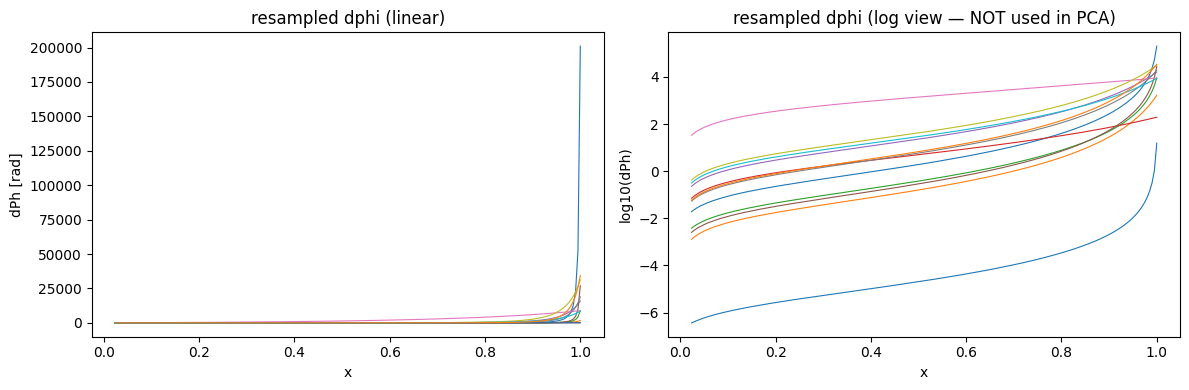

In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Build common x-grid and resample dphi (NOT ln dphi)               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
assert all((d[-1] == 0) and (d[:-1] > 0).all() for d in dphis), "unexpected zero pattern"

# Build x-axis and keep raw dphi (drop merger zero point)
xs, raw_dphis = [], []
for i in range(len(files)):
    x = (fs[i][:-1] - fc[i]) / (f_tau_arr[i] - fc[i])
    xs.append(x)
    raw_dphis.append(dphis[i][:-1])   # ← dphi, not log

assert all(len(x) == 199 for x in xs)

xmins = np.array([x.min() for x in xs])
xmaxs = np.array([x.max() for x in xs])
X_LO  = float(np.max(xmins))
X_HI  = float(np.min(xmaxs))
N_X   = 200
x_grid = np.linspace(X_LO, X_HI, N_X)
print(f"common x-grid: [{X_LO:.4f}, {X_HI:.4f}], {N_X} points")

# Resample onto common grid (x is decreasing → flip before interp)
Y = np.empty((len(files), N_X))
for i in range(len(files)):
    xi = xs[i][::-1]
    yi = raw_dphis[i][::-1]
    assert np.all(np.diff(xi) > 0), f"x not monotonically increasing after flip (system {i})"
    Y[i] = np.interp(x_grid, xi, yi)

# ── Sanity checks ──────────────────────────────────────────────────────────────
print(f"\nY shape       : {Y.shape}  (expected ({len(files)}, {N_X}))")
print(f"Y min         : {Y.min():.4e}  (must be > 0)")
print(f"Y max         : {Y.max():.4e}")
print(f"any Y <= 0    : {(Y <= 0).any()}  (must be False)")
print(f"Y decades span: {np.log10(Y.max()) - np.log10(Y.min()):.1f}")
print("⚠  PCA on raw dphi: components will reflect large dynamic range.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in np.random.choice(len(files), 12, replace=False):
    axes[0].plot(x_grid, Y[i], lw=0.8)
    axes[1].plot(x_grid, np.log10(Y[i]), lw=0.8)   # log-scale view for sanity
axes[0].set(xlabel="x", ylabel="dPh [rad]", title="resampled dphi (linear)")
axes[1].set(xlabel="x", ylabel="log10(dPh)", title="resampled dphi (log view — NOT used in PCA)")
plt.tight_layout(); plt.show()

# REsample onto common x-grid

In [19]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Train/val/test split + input standardization                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
theta_raw = np.column_stack([np.log(m1), np.log(m2), np.log(rho), gsp])

idx          = np.arange(len(files))
idx_trainval, idx_test  = train_test_split(idx, test_size=0.10, random_state=0)
idx_train,    idx_val   = train_test_split(idx_trainval, test_size=1/9, random_state=0)

# Convert to numpy arrays immediately — avoids all tensor-indexing bugs
idx_train_np = np.asarray(idx_train)
idx_val_np   = np.asarray(idx_val)
idx_test_np  = np.asarray(idx_test)

theta_mu  = theta_raw[idx_train_np].mean(0)
theta_std = theta_raw[idx_train_np].std(0)
theta     = (theta_raw - theta_mu) / theta_std

print(f"train/val/test = {len(idx_train_np)}/{len(idx_val_np)}/{len(idx_test_np)}")
print(f"theta shape: {theta.shape}")
print(f"theta (train) mean: {theta[idx_train_np].mean(0).round(4)}  (should be ~0)")
print(f"theta (train) std : {theta[idx_train_np].std(0).round(4)}   (should be ~1)")

train/val/test = 8000/1000/1000
theta shape: (10000, 4)
theta (train) mean: [ 0. -0. -0.  0.]  (should be ~0)
theta (train) std : [1. 1. 1. 1.]   (should be ~1)


# Inputs: log-transform and standardize

Explained variance (cumulative): [0.94128 0.99258 0.99902 0.99989 0.99999 1.      1.      1.      1.
 1.      1.      1.      1.      1.      1.      1.      1.      1.
 1.      1.      1.      1.      1.      1.      1.      1.      1.
 1.      1.      1.      1.      1.      1.      1.      1.      1.
 1.      1.      1.      1.      1.      1.      1.      1.      1.
 1.      1.      1.      1.      1.      1.      1.      1.      1.
 1.      1.      1.      1.      1.      1.     ]
Variance captured by K=60 components: 100.000%

coeffs shape    : (10000, 60)
coeffs_n shape  : (10000, 60)
coeffs raw  — min:-6.096e+05  max:2.489e+06  std:2.260e+04
coeffs_n    — min:-3.869e+01  max:4.206e+01  std:1.035e+00

y_tr shape : torch.Size([8000, 60])   (expected (8000, 60))
y_va shape : torch.Size([1000, 60])   (expected (1000, 60))
X_tr shape : torch.Size([8000, 4])   (expected (8000, 4))

⚠  WARNING: raw PCA coefficients have very large std — training on coeffs_n is critical!

PCA reconstru

/tmp/ipykernel_11824/2235328495.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


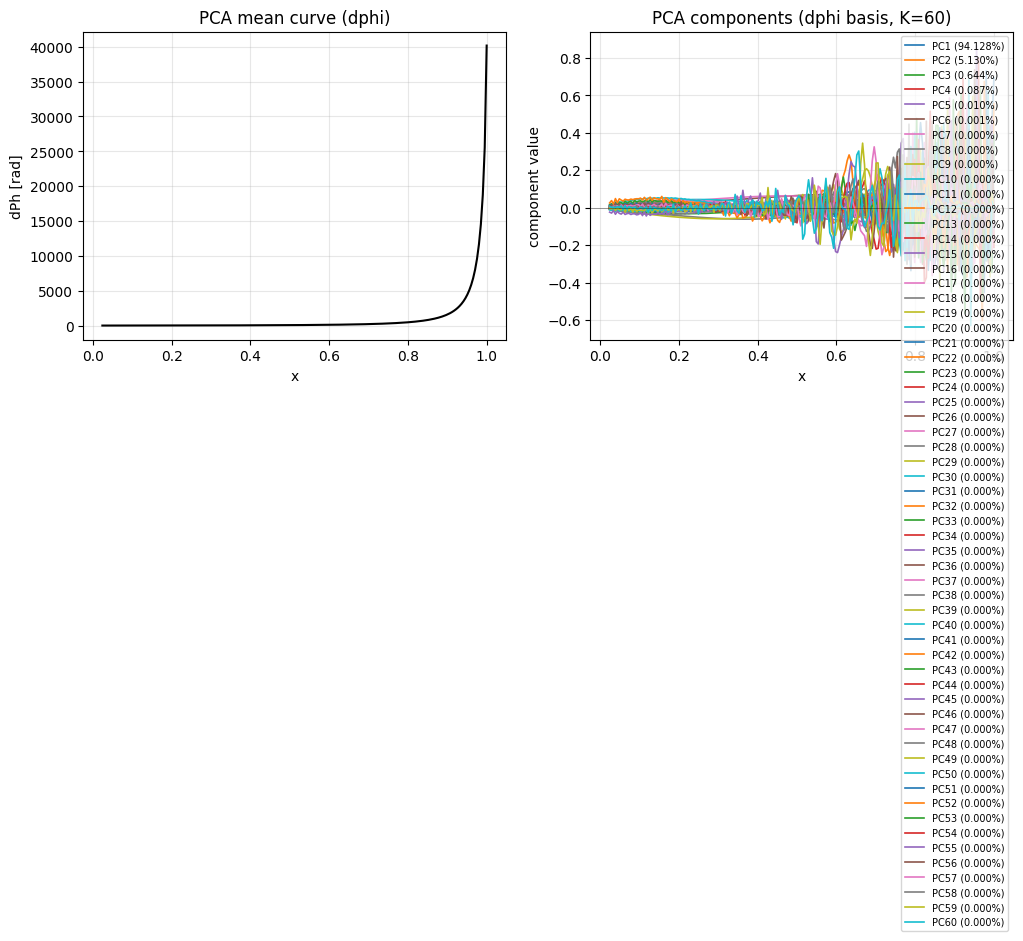

In [20]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — PCA on raw dphi + standardize coefficients                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
pca = PCA(n_components=K)
pca.fit(Y[idx_train_np])

cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f"Explained variance (cumulative): {cumvar.round(5)}")
print(f"Variance captured by K={K} components: {cumvar[-1]*100:.3f}%")

coeffs = pca.transform(Y)   # (N, K)

# Standardize using training stats only
c_mu  = coeffs[idx_train_np].mean(0)
c_std = coeffs[idx_train_np].std(0)
coeffs_n = (coeffs - c_mu) / c_std

# ── Build tensors immediately in same cell — no stale-tensor bugs ──────────────
def to_t(a): return torch.as_tensor(a, dtype=torch.float32, device=DEVICE)

X_tr, y_tr = to_t(theta[idx_train_np]), to_t(coeffs_n[idx_train_np])
X_va, y_va = to_t(theta[idx_val_np]),   to_t(coeffs_n[idx_val_np])
X_te, y_te = to_t(theta[idx_test_np]),  to_t(coeffs_n[idx_test_np])

# ── Sanity checks ──────────────────────────────────────────────────────────────
print(f"\ncoeffs shape    : {coeffs.shape}")
print(f"coeffs_n shape  : {coeffs_n.shape}")
print(f"coeffs raw  — min:{coeffs.min():.3e}  max:{coeffs.max():.3e}  std:{coeffs.std():.3e}")
print(f"coeffs_n    — min:{coeffs_n.min():.3e}  max:{coeffs_n.max():.3e}  std:{coeffs_n.std():.3e}")
print(f"\ny_tr shape : {y_tr.shape}   (expected ({len(idx_train_np)}, {K}))")
print(f"y_va shape : {y_va.shape}   (expected ({len(idx_val_np)}, {K}))")
print(f"X_tr shape : {X_tr.shape}   (expected ({len(idx_train_np)}, 4))")

# Warn if coefficients are exploding — this is the key dphi risk
if coeffs.std() > 1e4:
    print("\n⚠  WARNING: raw PCA coefficients have very large std — training on coeffs_n is critical!")
if coeffs_n[idx_train_np].std() > 5:
    print("⚠  WARNING: standardized coefficients still large — consider log-scaling dphi upstream.")

# PCA reconstruction check
Y_recon = pca.inverse_transform(coeffs[idx_train_np])
recon_err = np.abs(Y[idx_train_np] - Y_recon)
print(f"\nPCA reconstruction error on train — mean:{recon_err.mean():.3e}  max:{recon_err.max():.3e}")
print(f"Relative recon error (mean/mean(Y)): {recon_err.mean() / Y[idx_train_np].mean():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_grid, pca.mean_, "k-", lw=1.5)
axes[0].set(xlabel="x", ylabel="dPh [rad]", title="PCA mean curve (dphi)")
axes[0].grid(alpha=0.3)
for k in range(K):
    evr = pca.explained_variance_ratio_[k]
    axes[1].plot(x_grid, pca.components_[k], lw=1.2, label=f"PC{k+1} ({evr*100:.3f}%)")
axes[1].axhline(0, color="k", lw=0.5, alpha=0.5)
axes[1].set(xlabel="x", ylabel="component value", title=f"PCA components (dphi basis, K={K})")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# PCA Basis (train-only) -> project all curves

In [ ]:
import matplotlib.cm as cm

WIDTHS     = 64
MAX_LAYERS = 10
EPOCHS     = 2000
BATCH      = 1000

# Convert split indices to numpy once — avoids tensor indexing issues
idx_train_np = np.asarray(idx_train)
idx_val_np   = np.asarray(idx_val)
idx_test_np  = np.asarray(idx_test)

# Precompute per-sample S_n weights on the physical frequency axis
print("Precomputing S_n weights...")
sn_weights = np.zeros(len(theta))
for i in range(len(theta)):
    f_axis = x_grid * (f_tau_arr[i] - fc[i]) + fc[i]
    sn_weights[i] = np.mean(np.abs(np.log(S_n(f_axis))))
sn_weights_t = to_t(sn_weights)  # shape: (N_total,)

class MLP(nn.Module):
    def __init__(self, d_in=4, d_out=K, width=64, n_hidden=1):
        super().__init__()
        layers = [nn.Linear(d_in, width), nn.ReLU()]
        for _ in range(n_hidden - 1):
            layers += [nn.Linear(width, width), nn.ReLU()]
        layers.append(nn.Linear(width, d_out))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

all_val_rmse = {}  # n_layers -> list of per-epoch val RMSE


print("K        =", K)
print("y_tr     =", y_tr.shape)   # should be (N_train, 10)
print("y_va     =", y_va.shape)   # should be (N_val,   10)t
for n_layers in range(MAX_LAYERS, MAX_LAYERS + 1):
    print(f"\n=== n_hidden_layers={n_layers} ===")
    model   = MLP(width=WIDTHS, n_hidden=n_layers).to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.MSELoss()

    best_va    = float("inf")
    best_state = None
    hist       = {"train": [], "val": []}
    n_tr       = X_tr.shape[0]

    for epoch in range(EPOCHS):
        model.train()
        perm   = torch.randperm(n_tr, device=DEVICE)
        losses = []

        for s in range(0, n_tr, BATCH):
            b_idx  = perm[s:s+BATCH]                          # (batch,) indices into X_tr
            b_np   = b_idx.cpu().numpy()                      # numpy for fancy-indexing
            global_idx = idx_train_np[b_np]                   # map back to global system indices

            opt.zero_grad()
            pred = model(X_tr[b_idx])                         # (batch, K)

            diff           = (pred - y_tr[b_idx]) ** 2        # (batch, K)
            mse_per_sample = diff.mean(dim=1)                 # (batch,)
            w              = sn_weights_t[global_idx]         # (batch,)
            loss           = (mse_per_sample * w).mean()

            loss.backward()
            opt.step()
            losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            va = loss_fn(model(X_va), y_va).item()            # plain MSE for val

        hist["train"].append(float(np.mean(losses)))
        hist["val"].append(float(np.sqrt(va)))                # store as RMSE

        if va < best_va:
            best_va    = va
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

        if epoch % 100 == 0:
            print(f"  epoch {epoch:4d}  train {hist['train'][-1]:.4e}  val RMSE {hist['val'][-1]:.4e}")

    model.load_state_dict(best_state)
    all_val_rmse[n_layers] = hist["val"]
    print(f"  best val MSE = {best_va:.4e}")




Precomputing S_n weights...
K        = 60
y_tr     = torch.Size([8000, 60])
y_va     = torch.Size([1000, 60])

=== n_hidden_layers=10 ===
  epoch    0  train 9.1250e+01  val RMSE 1.2073e+00
  epoch  100  train 8.6655e+01  val RMSE 1.1863e+00
  epoch  200  train 8.3878e+01  val RMSE 1.1702e+00
  epoch  300  train 8.2513e+01  val RMSE 1.1616e+00
  epoch  400  train 8.1237e+01  val RMSE 1.1536e+00
  epoch  500  train 8.0193e+01  val RMSE 1.1500e+00
  epoch  600  train 7.9017e+01  val RMSE 1.1480e+00
  epoch  700  train 7.8309e+01  val RMSE 1.1451e+00
  epoch  800  train 7.7655e+01  val RMSE 1.1451e+00
  epoch  900  train 7.6984e+01  val RMSE 1.1451e+00
  epoch 1000  train 7.6341e+01  val RMSE 1.1484e+00
  epoch 1100  train 7.5702e+01  val RMSE 1.1491e+00
  epoch 1200  train 7.5237e+01  val RMSE 1.1518e+00


KeyError: 1

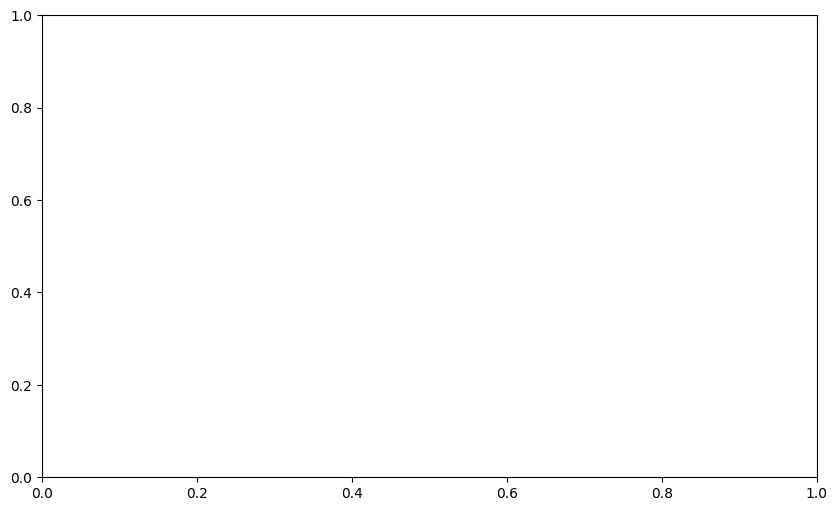

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Plot val RMSE curves                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(figsize=(10, 6))
cmap   = cm.plasma
colors = [cmap(i / (MAX_LAYERS - 1)) for i in range(MAX_LAYERS)]

for i, n_layers in enumerate(range(1, MAX_LAYERS + 1)):
    ax.plot(all_val_rmse[n_layers], color=colors[i], linewidth=1.5,
            label=f"{n_layers} layer{'s' if n_layers > 1 else ''}")

sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=MAX_LAYERS))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Number of hidden layers", fontsize=11)

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation RMSE (standardized coeffs)", fontsize=12)
ax.set_title(f"Val RMSE vs Epoch — width-{WIDTHS} MLPs on dphi PCA coefficients", fontsize=13)
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

best_layer = min(all_val_rmse, key=lambda k: min(all_val_rmse[k]))
print(f"Best architecture: {best_layer} hidden layer(s), "
      f"final val RMSE = {min(all_val_rmse[best_layer]):.4e}")

# MLP: 4 params -> K coeffictients

Y_te_pred shape  : (1000, 200)
Y_te_pred min    : -5.9030e+03  (⚠ negative = PCA overshoot in dphi space)
Y_te_pred max    : 1.3049e+06
Negative dphi predictions: 66183 / 200000  (33.09%)
  ⚠  Negative dphi values detected — PCA on raw dphi can produce this.
     They will be clipped to a small positive floor before mismatch eval.

test coefficient RMSE          : 4.5923e+03
test curve RMSE in dphi [rad]  : median 1.422e+02, mean 4.501e+02, p95 1.872e+03
relative error (RMSE/mean_dphi): median 1.857e+00
PCA basis floor                : 1.728e-01
model error above basis floor  : 4.499e+02


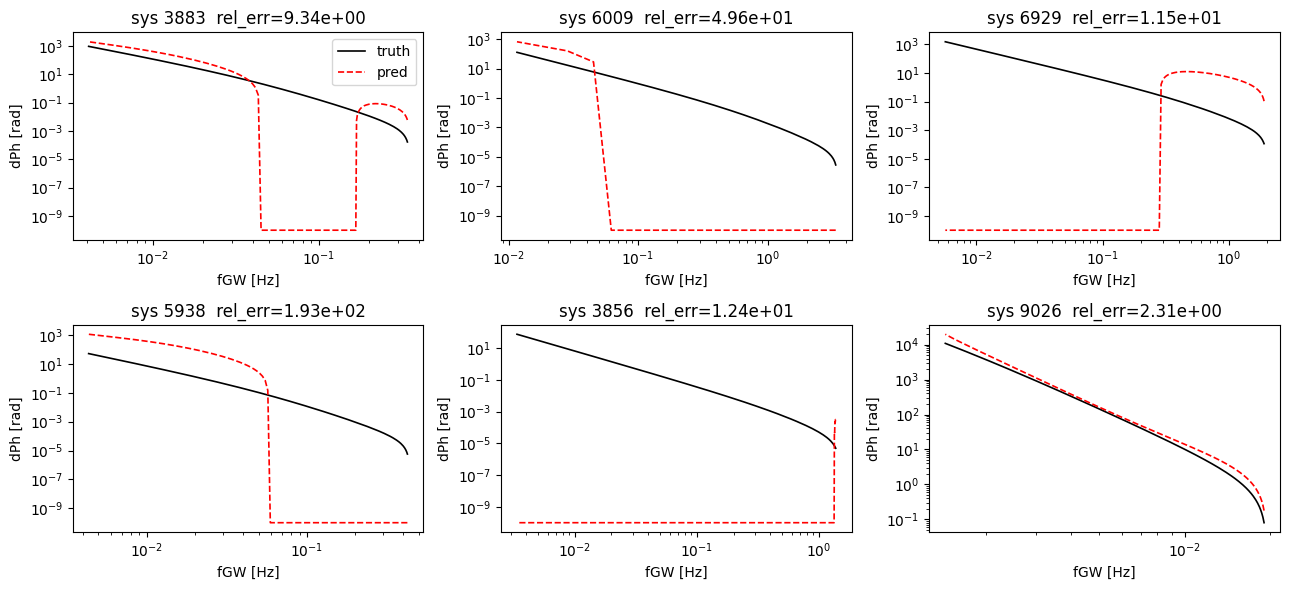

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Evaluation: reconstruct dphi curves from predictions             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
@torch.no_grad()
def predict_curves(theta_arr_norm):
    model.eval()
    c_n   = model(to_t(theta_arr_norm)).cpu().numpy()   # (N, K) normalized coeffs
    c     = c_n * c_std + c_mu                           # denormalize
    Y_hat = pca.inverse_transform(c)                     # (N, N_X) predicted dphi
    return c, Y_hat

c_te_pred, Y_te_pred = predict_curves(theta[idx_test_np])
c_te_true            = coeffs[idx_test_np]
Y_te_true            = Y[idx_test_np]

# ── Sanity checks ──────────────────────────────────────────────────────────────
print(f"Y_te_pred shape  : {Y_te_pred.shape}")
print(f"Y_te_pred min    : {Y_te_pred.min():.4e}  (⚠ negative = PCA overshoot in dphi space)")
print(f"Y_te_pred max    : {Y_te_pred.max():.4e}")
n_neg = (Y_te_pred <= 0).sum()
print(f"Negative dphi predictions: {n_neg} / {Y_te_pred.size}  ({100*n_neg/Y_te_pred.size:.2f}%)")
if n_neg > 0:
    print("  ⚠  Negative dphi values detected — PCA on raw dphi can produce this.")
    print("     They will be clipped to a small positive floor before mismatch eval.")

# Clip negatives for mismatch computation (physical dphi must be > 0)
DPHI_FLOOR    = 1e-10
Y_te_pred_safe = np.clip(Y_te_pred, DPHI_FLOOR, None)

# Coefficient-space error
coef_rmse = np.sqrt(((c_te_pred - c_te_true)**2).mean())
print(f"\ntest coefficient RMSE          : {coef_rmse:.4e}")

# Curve-space error in dphi units
err_dphi         = Y_te_pred_safe - Y_te_true
rmse_per_curve   = np.sqrt((err_dphi**2).mean(axis=1))
rel_err_per_curve = rmse_per_curve / Y_te_true.mean(axis=1)
print(f"test curve RMSE in dphi [rad]  : median {np.median(rmse_per_curve):.3e}, "
      f"mean {rmse_per_curve.mean():.3e}, p95 {np.quantile(rmse_per_curve, 0.95):.3e}")
print(f"relative error (RMSE/mean_dphi): median {np.median(rel_err_per_curve):.3e}")

# PCA basis floor
basis_floor = np.sqrt(((Y[idx_test_np] -
                         pca.inverse_transform(pca.transform(Y[idx_test_np])))**2)
                       .mean(axis=1)).mean()
print(f"PCA basis floor                : {basis_floor:.3e}")
print(f"model error above basis floor  : {rmse_per_curve.mean() - basis_floor:.3e}")

# Plot a few predictions vs truth
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
sel = np.random.choice(len(idx_test_np), 6, replace=False)
for ax, j in zip(axes.flat, sel):
    sys_i  = idx_test_np[j]
    f_axis = x_grid * (f_tau_arr[sys_i] - fc[sys_i]) + fc[sys_i]
    ax.plot(f_axis, Y_te_true[j],        "k-",  lw=1.2, label="truth")
    ax.plot(f_axis, Y_te_pred_safe[j],   "r--", lw=1.2, label="pred")
    ax.set(xscale="log", yscale="log",
           xlabel="fGW [Hz]", ylabel="dPh [rad]",
           title=f"sys {sys_i}  rel_err={rel_err_per_curve[j]:.2e}")
axes[0, 0].legend()
plt.tight_layout(); plt.show()

Critical mismatch M_c = 5.000e-05


/tmp/ipykernel_11824/4236000537.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 4 * np.real(np.trapz(np.conj(a) * b / S_n(f), f))



Mismatch statistics
-------------------
median : 7.580e-01
mean   : 7.068e-01
max    : 9.453e-01
min    : 0.000e+00

Fraction M > M_c : 0.996

Self-mismatch (truth vs truth, last system): 0.000e+00  (should be ~0)


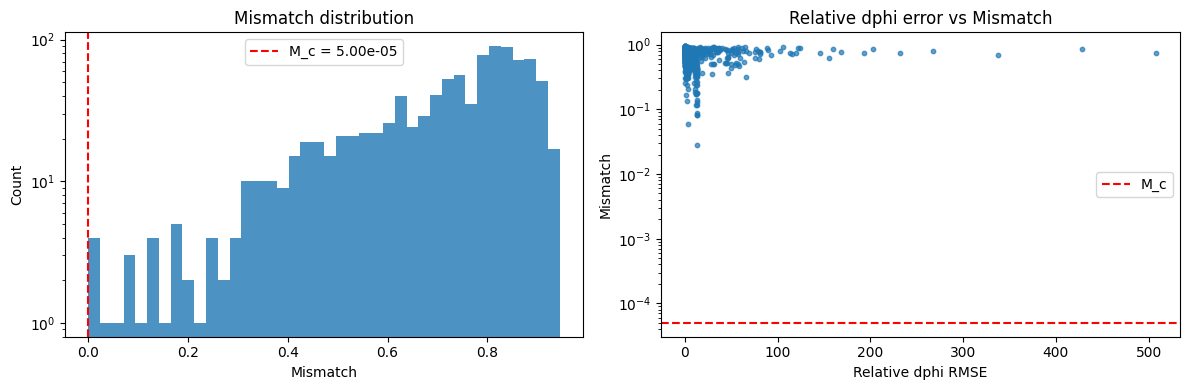

In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Mismatch evaluation                                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# (Physics helpers — same as original, no changes needed)
G_ph   = 6.67430e-11
c_ph   = 299792458.0
M_sun  = 1.98847e30
L_lisa = 2.5e9
f_star_lisa = c_ph / (2 * np.pi * L_lisa)

def phi_vacuum(f, chirp_mass):
    return (1/16) * (c_ph**3 / (np.pi * G_ph * chirp_mass * f))**(5/3)

def phi_ddot_vacuum(f, chirp_mass):
    a_V = (np.pi * G_ph * chirp_mass / c_ph**3)**(-5/3)
    return (12 * np.pi**2 * f**(11/3)) / (5 * a_V)

def h0(f, chirp_mass, phi_dd):
    prefactor = 0.5 * (4 * np.pi**(2/3) * G_ph**(5/3) * chirp_mass**(5/3) * f**(2/3)) / c_ph**4
    return prefactor * np.sqrt(2 * np.pi / phi_dd)

def build_waveform(f, delta_phi, m1_sol, m2_sol):
    m1_kg = m1_sol * M_sun;  m2_kg = m2_sol * M_sun
    Mc    = (m1_kg * m2_kg)**(3/5) / (m1_kg + m2_kg)**(1/5)
    phi_v = phi_vacuum(f, Mc)
    phi_env  = phi_v - delta_phi
    phi_dd   = phi_ddot_vacuum(f, Mc)
    return h0(f, Mc, phi_dd) * np.exp(1j * phi_env)

def inner_product(a, b, f):
    return 4 * np.real(np.trapz(np.conj(a) * b / S_n(f), f))

def overlap_maximized(h1, h2, f):
    df        = f[1] - f[0]
    integrand = np.conj(h1) * h2 / S_n(f)
    z         = 4 * np.fft.ifft(integrand) * len(f) * df
    return np.max(np.abs(z))

def faithfulness(f, dphi_true, dphi_pred, m1_sol, m2_sol):
    h_true = build_waveform(f, dphi_true,  m1_sol, m2_sol)
    h_pred = build_waveform(f, dphi_pred,  m1_sol, m2_sol)
    hd = overlap_maximized(h_pred, h_true, f)
    hh = np.real(inner_product(h_pred, h_pred, f))
    dd = np.real(inner_product(h_true, h_true, f))
    return float(np.clip(hd / np.sqrt(hh * dd), 0.0, 1.0))

def mismatch(f, dphi_true, dphi_pred, m1_sol, m2_sol):
    return 1 - faithfulness(f, dphi_true, dphi_pred, m1_sol, m2_sol)

def resample_waveform_data(f, dphi, n_points=4000):
    f_uniform    = np.linspace(f.min(), f.max(), n_points)
    dphi_uniform = interp1d(f, dphi, kind="cubic")(f_uniform)
    return f_uniform, dphi_uniform

M_c = (4 / 2) / 200**2
print(f"Critical mismatch M_c = {M_c:.3e}")

mismatches, faithfulnesses = [], []
for j in range(len(idx_test_np)):
    sys_i  = idx_test_np[j]
    f_axis = x_grid * (f_tau_arr[sys_i] - fc[sys_i]) + fc[sys_i]

    dphi_true = Y_te_true[j]             # already dphi, no exp() needed
    dphi_pred = Y_te_pred_safe[j]        # clipped to > 0

    f_dense, dphi_true_dense = resample_waveform_data(f_axis, dphi_true)
    _,       dphi_pred_dense = resample_waveform_data(f_axis, dphi_pred)

    M = mismatch(f_dense, dphi_true_dense, dphi_pred_dense, m1[sys_i], m2[sys_i])
    mismatches.append(M); faithfulnesses.append(1 - M)

mismatches      = np.array(mismatches)
faithfulnesses  = np.array(faithfulnesses)

# ── Sanity checks ──────────────────────────────────────────────────────────────
print("\nMismatch statistics")
print("-------------------")
print(f"median : {np.median(mismatches):.3e}")
print(f"mean   : {np.mean(mismatches):.3e}")
print(f"max    : {np.max(mismatches):.3e}")
print(f"min    : {np.min(mismatches):.3e}")
print(f"\nFraction M > M_c : {np.mean(mismatches > M_c):.3f}")

# Self-consistency check on last system
M_self = mismatch(f_dense, dphi_true_dense, dphi_true_dense, m1[sys_i], m2[sys_i])
print(f"\nSelf-mismatch (truth vs truth, last system): {M_self:.3e}  (should be ~0)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mismatches, bins=40, alpha=0.8)
axes[0].axvline(M_c, color="red", ls="--", label=f"M_c = {M_c:.2e}")
axes[0].set(xlabel="Mismatch", ylabel="Count", yscale="log", title="Mismatch distribution")
axes[0].legend()

axes[1].scatter(rel_err_per_curve, mismatches, s=10, alpha=0.7)
axes[1].axhline(M_c, color="red", ls="--", label="M_c")
axes[1].set(xlabel="Relative dphi RMSE", ylabel="Mismatch", yscale="log",
            title="Relative dphi error vs Mismatch")
axes[1].legend()
plt.tight_layout(); plt.show()

# Evaluation - RMSE

test coefficient MSE          : 2.1089e+07
test curve RMSE in ln(dPh)    : median 1.840e+02, mean 4.802e+02, p95 1.872e+03
≈ multiplicative error on dPh : median 7838623543460906733783103037009453250730577954899813207619118702941618627986587648.00%
basis floor (PCA reconstruction error) : 1.728e-01
model error: 4.800e+02 (model error above basis floor)


### Slice errors by parameter region

# Computing Mismatch

## Evaluating Mismatch

- Perfect: M=0
- acceptable GW models: $M \leq 10^{-3}$
- distinguishability threshold: $M_c = 5 * 10^{-5}$
